## Imports and functions

In [1]:
import numpy as np
from numpy.fft import fftshift, fft, ifft, rfft, irfft, fftfreq
from numpy.typing import NDArray
import json
from pathlib import Path
from scipy.constants import speed_of_light as C_MKS
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import voigt_profile
from scipy.signal import find_peaks

def load_avg_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads and averages all data files under the pug directory.

    Args:
        path (Path): Path to the directory containing the .bin files, typ. 
        'Channel1'.

    Returns:
        NDArray[np.complex128]: Averaged and carrier-offset interferogram.
    """
    data_files = path.glob('*.bin')
    data_list = []
    for fname in data_files:
        data_list.append(load_pug_bin(fname))

    # Handle different lengths by padding with NaN
    max_len = max(len(d) for d in data_list)
    matrix = np.full((max_len, len(data_list)), np.nan, dtype=complex)

    for i, d in enumerate(data_list):
        matrix[:len(d), i] = d

    # Compute average across files (ignoring NaNs for uneven lengths)
    avg_signal = np.nanmean(matrix, axis=1)
    return avg_signal

def load_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads a single .bin file in the method used by the PUG.

    Args:
        path (Path): Path to the .bin file.

    Returns:
        NDArray[np.complex128]: Carrier-subtracted interferogram.
    """
    # Load raw binary floats (32-bit)
    numbers = np.fromfile(path, dtype=np.float32)

    # Convert to complex: (real, imag) pairs
    complex_data = numbers[0::2] + 1j * numbers[1::2]
    return complex_data

def load_json(path: Path) -> dict:
    """
    Loads a .json file as a dictionary.

    Args:
        path (Path): Path to .json file.

    Returns:
        dict: Contents of the file.
    """
    with open(path, 'r') as f:
        return json.load(f)                                                        

def load_pug(path) -> tuple[dict, NDArray] | tuple[None, None]:
    """
    Opens a dialog to ask the user for the PUG's data directory. Loads data exported from the PUG.

    Returns:
        tuple[dict, NDArray]|tuple[None,None]: A parameter dictionary and a complex,
        averaged data array. Returns None for both if the dialog is canceled.
    """
    apriori = load_json(path / 'apriori_params.json')
    computed =load_json(path / 'computed_params.json')
    gage = load_json(path / 'gageCard_params.json')
    avg_data = load_avg_pug_bin(path / 'Output_data/Channel1')
    params = {}
    params.update(apriori)
    params.update(computed)
    params.update(gage)
    return params, avg_data

def calc_absorbance(spectrum):
    """
    Calculates the absorbance of the spectrum and updates internal variables.
    """

    return - np.log(spectrum) 

def calc_cepstral_modified_igm(absorbance, optical_axis, time_axis, freq_cuton: float, freq_cutoff: float): 
    """
    Calculates the modified igm based on the absorbance and updates internal values for
    it and the associated time and frequency axes.

    Args:
        freq_cuton (flaot): Start of the absorbance window 
        freq_cutoff (float): End of the absorbance window
    """
    # Cut axis and absorbance based on window bounds
    mask = (optical_axis >= freq_cuton) & (optical_axis <= freq_cutoff)
    cepstral_optical_axis = optical_axis[mask]
    absorbance_cut = absorbance[mask]

    # Calculate modified igm
    # mod_igm = irfft(absorbance_cut)
    mod_igm = ifft(absorbance_cut)

    # Calculate time axis
    cep_time_axis = np.linspace(
        time_axis[0], time_axis[-1], len(mod_igm))

    # Update internal variables
    cepstral_time_axis = cep_time_axis
    mod_igm = mod_igm
    return mod_igm, cepstral_optical_axis, cepstral_time_axis

def calc_cepstral_spectrum(mod_igm, cep_time_axis, time_cutons: float, time_cutoffs:float, filter='step'):
    """
    Calculates the background-subtracted spectrum and updates internal variables.

    Args:
        time_cutons (float): Start of 
        time_cutoffs (float): _description_
        filter (str, optional): _description_. Defaults to 'step'.

    Raises:
        ValueError: _description_
    """        
    if not isinstance(time_cutons, (list, tuple)):
        cutons = [time_cutons]
    else:
        cutons = time_cutons

    if not isinstance(time_cutoffs, (list, tuple)):
        cutoffs = [time_cutoffs]
    else:
        cutoffs = time_cutoffs


    for cuton, cutoff in zip(cutons, cutoffs):
        if filter == 'step':
            mask = (cep_time_axis >= cuton) & (cep_time_axis <= cutoff)
            mod_igm[mask] = 0
        else:
            raise ValueError(
                f'\"{filter}\" is not a valid input for argument filter')

    # cepstral_absorbance = -rfft(mod_igm)
    cepstral_absorbance = -fft(mod_igm)
    return np.abs(np.exp(cepstral_absorbance))  

def alias_frequency(f0, df, fs):
    """
    Compute the aliased frequency of a signal after shifting.

    Parameters:
        f0 : float
            Initial frequency (Hz)
        df : float
            Frequency shift applied before sampling (Hz)
        fs : float
            Sampling rate (Hz)

    Returns:
        float: Aliased frequency (Hz), in range [-fs/2, fs/2)
    """
    f = f0 + df
    return ((f + fs/2) % fs) - fs/2


## Cepstral 

In [3]:
path = Path(r"C:\Users\mike\Documents\School\Research\Diddams\data\20251024_11h11m54s")
exp_params, avg_signal = load_pug(path)

1934050
3021954
11000129.976362988
11000031.896999985
3.0
460000000000000.0 610000000000000.0


C:\Users\mike\AppData\Local\Temp\ipykernel_33724\4181962163.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


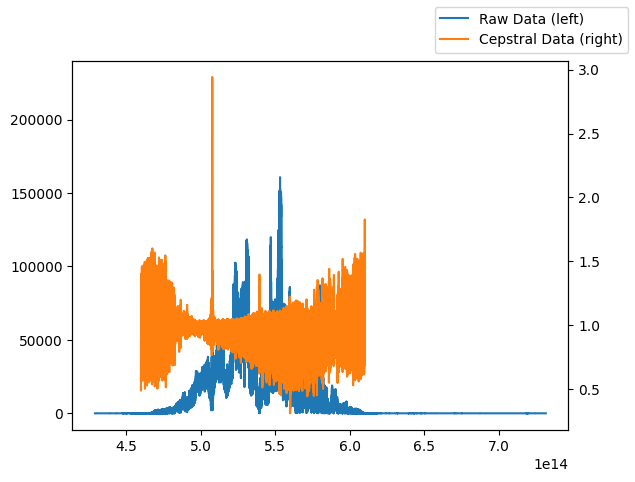

In [7]:
fb1 = -36e6
fb2 = 27e6
f01 = -35e6
f02 = -36e6
fr1 = exp_params['fr_approx_Hz']
dfr = exp_params['dfr']
sample_rate = exp_params['sampling_rate_Hz']
nu_cw = C_MKS / exp_params['reference1_laser_wvl_nm'] * 1e9
cw_mode1 = round((nu_cw + fb1 - f01) / fr1)
print(cw_mode1)
harmonic = exp_params['nb_harmonic']
extra_ref_slope_factor = exp_params['extra_ref_slope_factor']

ppigm = len(avg_signal)
print(ppigm)

electrical_freq_cw_tooth_true = alias_frequency((fb1 - fb2)*harmonic, 0, fr1 + dfr)
print(electrical_freq_cw_tooth_true)
electrical_freq_cw_tooth_sampled = alias_frequency((fb1 - fb2+ extra_ref_slope_factor * sample_rate / 2/ np.pi)*harmonic, 0, sample_rate)
print(electrical_freq_cw_tooth_sampled)
ntooth_shift =  np.round(np.abs(electrical_freq_cw_tooth_sampled - electrical_freq_cw_tooth_true)/dfr) 
print(ntooth_shift)

axis_norm = fftshift(fftfreq(ppigm))
axis_N = axis_norm * ppigm
axis_shift = harmonic * ((cw_mode1) * fr1 + f01) + ntooth_shift * fr1 
# Still need to derive extra mode offset
raw_optical_axis = (axis_N ) * fr1 + axis_shift

raw_spectrum = np.flip(np.abs(fftshift(fft(avg_signal))))

absorbance = calc_absorbance(raw_spectrum)

time_axis = np.linspace(0, 1/ sample_rate, ppigm)
freq_cuton, freq_cutoff = (460e12, 610e12)
print(freq_cuton,freq_cutoff)
mod_igm, cepstral_optical, cepstral_time = calc_cepstral_modified_igm(absorbance, raw_optical_axis, time_axis, freq_cuton, freq_cutoff)

time_cutons, time_cutoffs = ([0, 845e-12], [31.2e-12 ,1/sample_rate + 1])
cepstral_spectrum_full = calc_cepstral_spectrum(np.copy(mod_igm), cepstral_time, time_cutons, time_cutoffs)
# Plot comparison
f, ax = plt.subplots()
ax2 = plt.twinx()
ax.plot(raw_optical_axis, raw_spectrum, color='tab:blue', label="Raw Data (left)")
# ax2.plot(peak_axis, unshift_spectrum, 'r-', label='Model (right)')
ax2.plot(cepstral_optical, cepstral_spectrum_full, color='tab:orange', label='Cepstral Data (right)')
# ax.set_xlim(nu0_D1 - 5e9, nu0_D1 + 5e9)
f.legend()
f.show()
